# Chapter 1: Exploratory Data Analysis (EDA)
**Buku:** *Practical Statistics for Data Scientists (2nd Edition)* — Peter Bruce, Andrew Bruce, & Peter Gedeck

---

## 1. Chapter Summary
Exploratory Data Analysis (EDA) yang dipelopori oleh John Tukey merupakan langkah fundamental dalam memahami karakteristik data sebelum melakukan pemodelan. Berbeda dengan statistik inferensial tradisional yang berfokus pada populasi berbasis sampel kecil, sains data modern menekankan eksplorasi data secara visual dan komputasional pada data berstruktur tabular.

Bab ini berfokus pada beberapa konsep utama:
1. **Estimates of Location (Ukuran Pemusatan):** Menghitung nilai tipikal data menggunakan mean, trimmed mean, median, serta weighted mean/median.
2. **Estimates of Variability (Ukuran Variabilitas):** Menilai sebaran data melalui deviasi standar, varians, Median Absolute Deviation (MAD), dan Interquartile Range (IQR).
3. **Exploring Data Distribution (Eksplorasi Distribusi Data):** Memvisualisasikan sebaran data dengan boxplot, tabel frekuensi, histogram, serta kurva estimasi densitas kernel (KDE).
4. **Exploring Binary and Categorical Data (Data Kategorikal & Biner):** Menganalisis frekuensi kelas, modus, nilai harapan (*expected value*), serta diagram batang (*bar chart*).
5. **Correlation & Multivariate Analysis (Korelasi & Hubungan Antar Variabel):** Mengukur korelasi numerik Pearson, matriks korelasi (heatmap), *hexagonal binning*, peta kontur (KDE 2D), tabel kontingensi, dan *violin plot*.

In [48]:
# Install missing libraries
!pip install wquantiles

# Import library pendukung
%matplotlib inline
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt


# Definisi jalur folder data
# Updated path to look for 'data' folder inside the mounted Google Drive
DATA = Path('/content/drive/MyDrive/Colab Notebooks/data')
STATE_CSV = DATA / 'state.csv'
AIRPORT_DELAYS_CSV = DATA / 'dfw_airline.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv'
SP500_SECTORS_CSV = DATA / 'sp500_sectors.csv'
KC_TAX_CSV = DATA / 'kc_tax.csv'
LC_LOANS_CSV = DATA / 'lc_loans.csv'
AIRLINE_STATS_CSV = DATA / 'airline_stats.csv'


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## 2. Estimates of Location (Ukuran Pemusatan Data)

### Theoretical Explanation
Ukuran pemusatan digunakan untuk menemukan satu nilai yang paling merepresentasikan titik tengah atau konsentrasi data:

* **Mean (Rata-rata):** Jumlah seluruh data dibagi banyaknya observasi. Kelemahannya adalah sangat rentan terhadap *outlier*.
  $$\bar{x} = \frac{\sum_{i=1}^n x_i}{n}$$

* **Trimmed Mean (Rata-rata Terpangkas):** Dihitung setelah membuang persentase tertentu ($p$) dari data terkecil dan terbesar untuk meminimalkan pengaruh nilai ekstrem.
  $$\bar{x}_{\text{trim}} = \frac{\sum_{i=p+1}^{n-p} x_{(i)}}{n - 2p}$$

* **Median:** Nilai tengah setelah data diurutkan. Merupakan ukuran yang kuat (*robust*) terhadap nilai pencilan.

* **Weighted Mean & Weighted Median:** Digunakan jika observasi memiliki tingkat kepentingan atau bobot ($w_i$) populasi yang berbeda.
  $$\bar{x}_{\text{weighted}} = \frac{\sum_{i=1}^n w_i x_i}{\sum_{i=1}^n w_i}$$


In [34]:
# Memuat data state
try:
    state = pd.read_csv(STATE_CSV)
    print("Pratinjau Data State:")
    display(state.head())

    # Perhitungan ukuran pemusatan populasi negara bagian
    mean_val = state['Population'].mean()
    trim_val = trim_mean(state['Population'], 0.1)  # memotong 10% di kedua sisi
    median_val = state['Population'].median()

    print(f"Mean Populasi: {mean_val:,.0f}")
    print(f"Trimmed Mean Populasi (10%): {trim_val:,.0f}")
    print(f"Median Populasi: {median_val:,.0f}")

    # Weighted Mean dan Weighted Median untuk Murder Rate dengan bobot Population
    w_mean = np.average(state['Murder.Rate'], weights=state['Population'])
    w_median = wquantiles.median(state['Murder.Rate'], weights=state['Population'])

    print(f"\nRata-rata Tingkat Pembunuhan (Unweighted): {state['Murder.Rate'].mean():.2f}")
    print(f"Weighted Mean Tingkat Pembunuhan: {w_mean:.2f}")
    print(f"Weighted Median Tingkat Pembunuhan: {w_median:.2f}")
except Exception as e:
    print(f"Pastikan file data tersedia di path {DATA}. Error: {e}")

Pratinjau Data State:


,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


Mean Populasi: 6,162,876
Trimmed Mean Populasi (10%): 4,783,697
Median Populasi: 4,436,370

Rata-rata Tingkat Pembunuhan (Unweighted): 4.07
Weighted Mean Tingkat Pembunuhan: 4.45
Weighted Median Tingkat Pembunuhan: 4.40


In [35]:
print('Listing files in current directory:')
!ls -F

print('\nListing files in /content/data/ if it exists:')
!ls -F /content/data/

print('\nListing files in /content/ if state.csv was directly uploaded:')
!ls -F /content/state.csv


Listing files in current directory:
drive/	sample_data/

Listing files in /content/data/ if it exists:
ls: cannot access '/content/data/': No such file or directory

Listing files in /content/ if state.csv was directly uploaded:
ls: cannot access '/content/state.csv': No such file or directory


In [36]:
print('Listing files in sample_data/:')
!ls -F sample_data/

Listing files in sample_data/:
anscombe.json*		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md*


---
## 3. Estimates of Variability (Ukuran Variabilitas Data)

### Theoretical Explanation
Variabilitas atau dispersi mengukur seberapa jauh nilai-nilai data tersebar dari pusatnya:

* **Standar Deviasi ($s$) dan Varians ($s^2$):** Mengukur rata-rata penyimpangan kuadrat dari nilai mean.
  $$s = \sqrt{\frac{\sum_{i=1}^n (x_i - \bar{x})^2}{n - 1}}$$

* **Interquartile Range (IQR):** Selisih antara persentil ke-75 ($Q_3$) dan persentil ke-25 ($Q_1$). Bersifat tahan terhadap pencilan.
  $$\text{IQR} = Q_3 - Q_1$$

* **Median Absolute Deviation (MAD):** Nilai median dari selisih absolut masing-masing titik terhadap median.
  $$\text{MAD} = \text{Median}(|x_1 - m|, |x_2 - m|, \dots, |x_n - m|)$$


In [37]:
try:
    # Menghitung metrik variabilitas populasi
    std_dev = state['Population'].std()
    iqr_val = state['Population'].quantile(0.75) - state['Population'].quantile(0.25)
    mad_val = robust.scale.mad(state['Population'])

    print(f"Standar Deviasi Populasi: {std_dev:,.0f}")
    print(f"Interquartile Range (IQR): {iqr_val:,.0f}")
    print(f"Median Absolute Deviation (MAD): {mad_val:,.0f}")
except Exception as e:
    print(f"Error saat memproses variabilitas: {e}")

Standar Deviasi Populasi: 6,848,235
Interquartile Range (IQR): 4,847,308
Median Absolute Deviation (MAD): 3,849,876


---
## 4. Exploring the Data Distribution (Eksplorasi Bentuk Distribusi)

### Theoretical Explanation
* **Persentil & Boxplot:** Persentil membagi data ke dalam rentang persentase tertentu. Boxplot memvisualisasikan $Q_1$, median ($Q_2$), $Q_3$, serta batas rentang non-ekstrem (*whiskers*, maksimal $1.5 \times \text{IQR}$). Data di luar garis *whiskers* digambarkan sebagai titik tersendiri (kandidat outlier).
* **Histogram:** Membagi data kontinu ke dalam interval (*bins*) yang sama lebar dan memplot frekuensi pengamatan di tiap interval.
* **Density Plot (KDE):** Kurva halus probabilitas densitas yang diestimasi dari data, di mana luas area total di bawah kurva sama dengan 1.


Persentil Murder Rate:
0.05    1.600
0.25    2.425
0.50    4.000
0.75    5.550
0.95    6.510
Name: Murder.Rate, dtype: float64


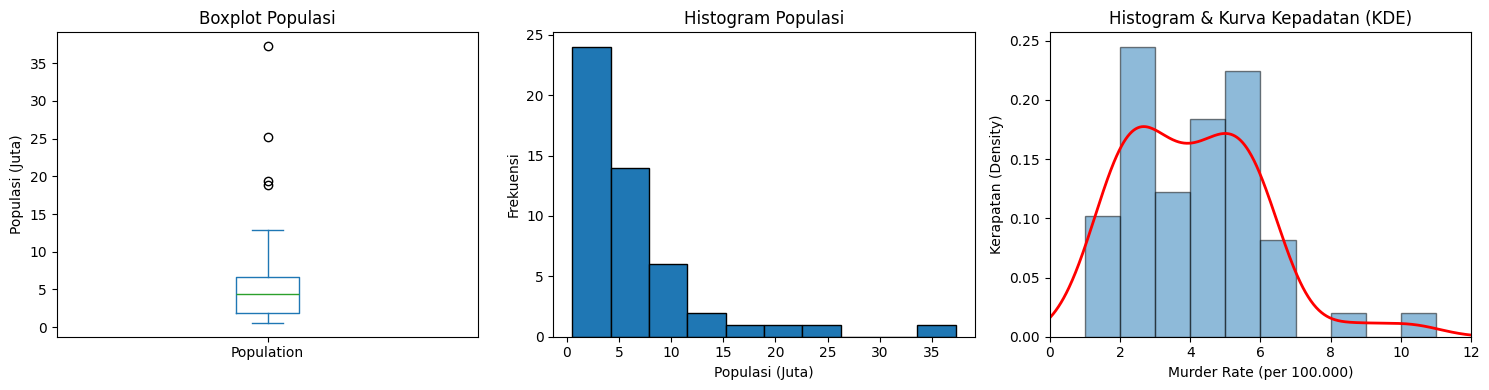

In [38]:
try:
    # 1. Tabel Persentil Tingkat Pembunuhan (Murder Rate)
    pct_table = state['Murder.Rate'].quantile([0.05, 0.25, 0.50, 0.75, 0.95])
    print("Persentil Murder Rate:")
    print(pct_table)

    # 2. Visualisasi Boxplot, Histogram, dan Density Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Boxplot
    (state['Population'] / 1_000_000).plot.box(ax=axes[0])
    axes[0].set_ylabel('Populasi (Juta)')
    axes[0].set_title('Boxplot Populasi')

    # Histogram
    (state['Population'] / 1_000_000).plot.hist(ax=axes[1], bins=10, edgecolor='black')
    axes[1].set_xlabel('Populasi (Juta)')
    axes[1].set_ylabel('Frekuensi')
    axes[1].set_title('Histogram Populasi')

    # Histogram + Density Plot
    state['Murder.Rate'].plot.hist(density=True, xlim=[0, 12], bins=range(1, 12), ax=axes[2], edgecolor='black', alpha=0.5)
    state['Murder.Rate'].plot.density(ax=axes[2], color='red', linewidth=2)
    axes[2].set_xlabel('Murder Rate (per 100.000)')
    axes[2].set_ylabel('Kerapatan (Density)')
    axes[2].set_title('Histogram & Kurva Kepadatan (KDE)')

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error saat visualisasi distribusi: {e}")

---
## 5. Exploring Binary and Categorical Data

### Theoretical Explanation
Data kualitatif/kategorikal diukur melalui frekuensi kemunculan dan proporsinya:
* **Modus (*Mode*):** Nilai kategori dengan kemunculan paling tinggi.
* **Expected Value (Nilai Harapan):** Rata-rata bobot kategori terhadap probabilitas terjadinya.
  $$E[X] = \sum x_i \cdot P(x_i)$$
* **Bar Chart:** Diagram visualisasi kategori dengan sumbu tegak menunjukkan jumlah atau proporsi, dan sumbu datar berisi kategori tanpa urutan kontinu numerik.


Data Keterlambatan DFW Airport:


,Carrier,ATC,Weather,Security,Inbound
0,64263.16,84856.5,11235.42,343.15,118427.82


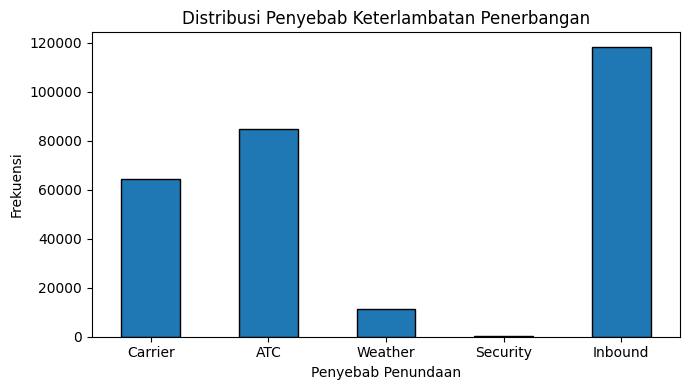

In [39]:
try:
    # Membaca data keterlambatan penerbangan di bandara DFW
    dfw = pd.read_csv(AIRPORT_DELAYS_CSV)
    print("Data Keterlambatan DFW Airport:")
    display(dfw)

    # Diagram Batang
    ax = dfw.transpose().plot.bar(figsize=(7, 4), legend=False, edgecolor='black')
    ax.set_xlabel('Penyebab Penundaan')
    ax.set_ylabel('Frekuensi')
    ax.set_title('Distribusi Penyebab Keterlambatan Penerbangan')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error saat memuat/visualisasi keterlambatan DFW: {e}")

---
## 6. Correlation (Korelasi Numerik)

### Theoretical Explanation
Korelasi linear Pearson mengukur hubungan kovariansi terstandarisasi antara dua variabel kontinu $X$ dan $Y$ dalam rentang $[-1, 1]$:
$$r = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{(n - 1)s_x s_y}$$
Nilai mendekati $+1$ mengindikasikan korelasi positif kuat, nilai mendekati $-1$ menunjukkan korelasi negatif kuat, dan $0$ menandakan tiadanya hubungan linier.


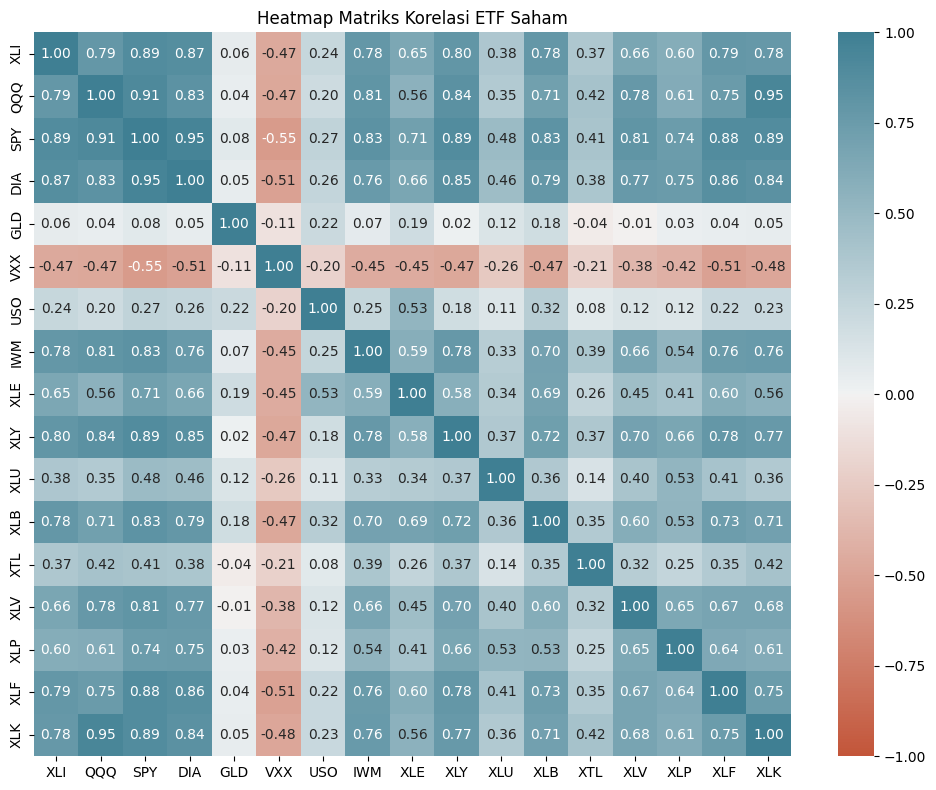

In [49]:
try:
    # Memuat data return indeks saham dan informasi sektor
    sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)
    sp500_sym = pd.read_csv(SP500_SECTORS_CSV)

    # Memfilter ETF utama sejak Juli 2012
    etf_symbols = sp500_sym[sp500_sym['sector'] == 'etf']['symbol']
    etfs = sp500_px.loc[sp500_px.index > '2012-07-01', etf_symbols]

    # Matriks Korelasi
    corr_matrix = etfs.corr()

    # Visualisasi Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, vmin=-1, vmax=1, cmap=sns.diverging_palette(20, 220, as_cmap=True),
                annot=True, fmt='.2f', cbar=True)
    plt.title('Heatmap Matriks Korelasi ETF Saham')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error saat menghitung korelasi SP500: {e}")

---
## 7. Exploring Two or More Variables (Analisis Bivariat & Multivariat)

### Theoretical Explanation
Ketika ukuran sampel sangat besar, *scatterplot* standar akan mengalami *overplotting* (tumpukan titik hitam pekat). Pendekatan yang dianjurkan meliputi:
1. **Hexagonal Binning:** Mengelompokkan titik data ke dalam heksagon-heksagon kecil dengan variasi warna intensitas sesuai kerapatan titik.
2. **Contour Plot:** Memetakan kerapatan kepadatan bivariat dua dimensi seperti peta topografi.
3. **Tabel Kontingensi:** Tabulasi silang antar kategori untuk melihat frekuensi bersama.
4. **Violin Plot:** Kombinasi visualisasi distribusi kepadatan (KDE) simetris dengan penanda kuartil di dalamnya.
5. **Faceting:** Mengelompokkan visualisasi bivariat ke dalam panel-panel terpisah berdasarkan variabel ketiga (*conditioning variable*).


Path KC_TAX_CSV yang digunakan: /content/drive/MyDrive/Colab Notebooks/data/kc_tax.csv


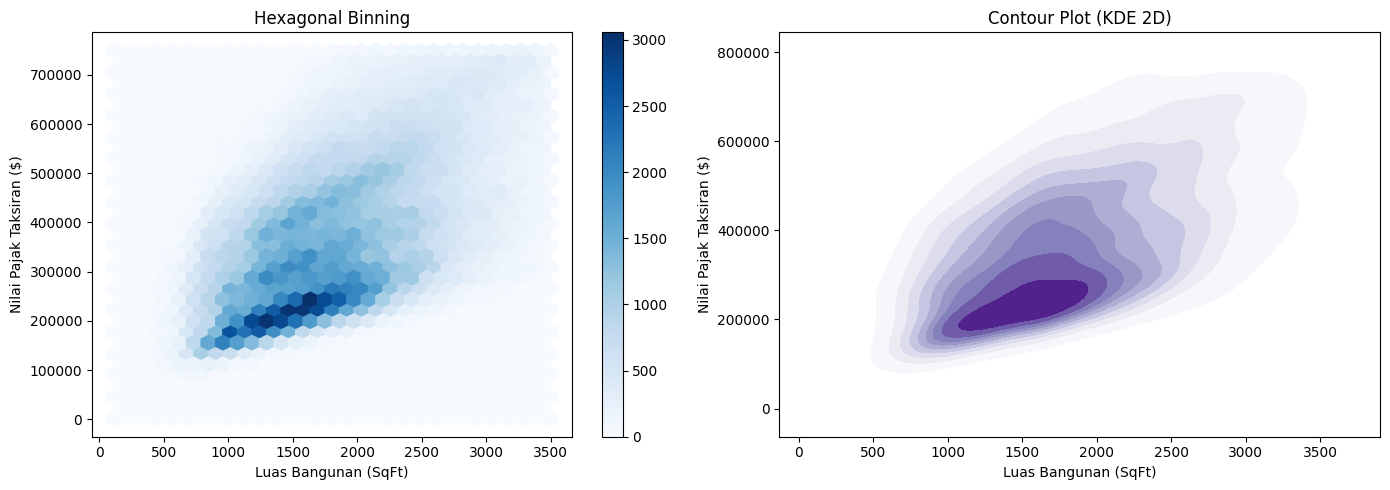

Error pada visualisasi multivariat: 'str' object is not callable


In [55]:
try:
    # 1. Hexagonal Binning & Contour Plot (King County Tax Data)
    print(f"Path KC_TAX_CSV yang digunakan: {KC_TAX_CSV}")
    kc_tax = pd.read_csv(KC_TAX_CSV)

    # Filter subset representatif
    kc_tax0 = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                         (kc_tax.SqFtTotLiving > 100) &
                         (kc_tax.SqFtTotLiving < 3500), :]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Hexbin Plot
    kc_tax0.plot.hexbin(x='SqFtTotLiving', y='TaxAssessedValue', gridsize=30,
                        sharex=False, cmap='Blues', ax=axes[0])
    axes[0].set_xlabel('Luas Bangunan (SqFt)')
    axes[0].set_ylabel('Nilai Pajak Taksiran ($)')
    axes[0].set_title('Hexagonal Binning')

    # Contour Plot
    kc_sample = kc_tax0.sample(10000, random_state=42)
    sns.kdeplot(data=kc_sample, x='SqFtTotLiving', y='TaxAssessedValue', ax=axes[1], cmap='Purples', fill=True)
    axes[1].set_xlabel('Luas Bangunan (SqFt)')
    axes[1].set_ylabel('Nilai Pajak Taksiran ($)')
    axes[1].set_title('Contour Plot (KDE 2D)')

    plt.tight_layout()
    plt.show()

    # 2. Tabel Kontingensi (Lending Club)
    lc_loans = pd.read_csv(LC_LOANS_CSV)
    crosstab = lc_loans.pivot_table(index='grade', columns='status', aggfunc='size', margins=True)
    print("\nTabel Kontingensi Status Pinjaman vs Grade:")
    display(crosstab)

    # 3. Violin Plot Keterlambatan Maskapai
    airline_stats = pd.read_csv(AIRLINE_STATS_CSV)
    plt.figure(figsize=(9, 4))
    sns.violinplot(data=airline_stats, x='airline', y='pct_carrier_delay', inner='quartile', palette='Set2')
    plt.xlabel('Maskapai')
    plt.ylabel('Persentase Delay Harian (%)')
    plt.title('Violin Plot Persentase Keterlambatan Berdasarkan Maskapai')
    plt.ylim(0, 50)
    plt.tight_layout()
    plt.show()

    # 4. Faceting / Conditioning berdasarkan Zip Code
    zip_codes = [98188, 98105, 98108, 98126]
    kc_tax_zip = kc_tax0.loc[kc_tax0.ZipCode.isin(zip_codes), :]

    def hexbin_facet(x, y, color, **kwargs):
        cmap = sns.light_palette(color, as_cmap=True)
        plt.hexbin(x, y, gridsize=25, cmap=cmap, **kwargs)

    g = sns.FacetGrid(kc_tax_zip, col='ZipCode', col_wrap=2, height=3.5, aspect=1.3)
    g.map(hexbin_facet, 'SqFtTotLiving', 'TaxAssessedValue', extent=[0, 3500, 0, 700000])
    g.set_axis_labels('Luas Bangunan (SqFt)', 'Nilai Pajak ($)')
    g.set_titles(col_template='Kode Pos: {col_name:.0f}')
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle('Hexbin Plot Terkondisi Berdasarkan Kode Pos')
    plt.show()
except Exception as e:
    print(f"Error pada visualisasi multivariat: {e}")